In [1]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:

from typing import Dict, Tuple, List, Optional
import numpy as np
import pandas as pd
import logging
logger = logging.getLogger(__name__)

def load_ap1_data_from_csv(csv_filepath: str, replicate: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Loads AP1 single-cell data from CSV or Excel file.

    Args:
        csv_filepath: Path to the CSV or Excel file

    Returns:
        Dictionary with condition identifiers as keys and feature matrices as values
    """
    logger.info(f"Loading data from: {csv_filepath}")

    # Load the data based on file extension
    if csv_filepath.endswith('.csv'):
        df = pd.read_csv(csv_filepath)
    elif csv_filepath.endswith('.xlsx'):
        df = pd.read_excel(csv_filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    
    replacement_map = {
                        '0.316 uM Vemurafenib': 'Vem',
                        '0.316 uM Vem + 0.0316 uM Tram': 'Vem+Tram'
                        }
    df['condition'] = df['condition'].replace(replacement_map)

    print(df['condition'].unique())

    # Define AP1 protein features (these are in log space already)
    ap1_features = [
        'cFOS (log a.u.)', 'p-cFOS (log a.u.)', 'FRA1 (log a.u.)', 'p-FRA1 (log a.u.)', 'FRA2 (log a.u.)',
        'cJUN (log a.u.)', 'p-cJUN (log a.u.)', 'JUNB (log a.u.)', 'JUND (log a.u.)', 'p-ATF1 (log a.u.)',
        'ATF2 (log a.u.)',	 'p-ATF2 (log a.u.)', 'ATF3 (log a.u.)', 'ATF4 (log a.u.)', 'p-ATF4 (log a.u.)',
        'ATF5 (log a.u.)', 'ATF6 (log a.u.)', 'MITF (log a.u.)', 'NGFR (log a.u.)', 'p-ERK (log a.u.)',
    ]

    # Check if all features exist
    missing_features = [f for f in ap1_features if f not in df.columns]
    if missing_features:
        logger.warning(f"Missing features: {missing_features}")
        ap1_features = [f for f in ap1_features if f in df.columns]

    logger.info(f"Using {len(ap1_features)} AP1 features")

    # Create condition-based data dictionary
    data_dict = {}

    if replicate is not None:
        # Group by condition, time, and cell line
        for (condition, time, cell_line, replicate_id), group in df.groupby(['condition', 'time', 'cell_line', 'replicate_id']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}_rep{replicate_id}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")
    else:
        # Group by condition, time, and cell line
        for (condition, time, cell_line), group in df.groupby(['condition', 'time', 'cell_line']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")

    return data_dict

def prepare_pair_from_mat(cell_line: str,
                          baseline_condition: str, baseline_time: str,
                          target_condition: str, target_time: str,
                          replicate: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    print("Cell line: ", cell_line)
    raw_data_dict = load_ap1_data_from_csv('mmc5.xlsx', replicate)

    if replicate is not None:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}_rep{replicate}"
        post_key = f"{cell_line}_{target_condition}_{target_time}_rep{replicate}"
    else:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}"
        post_key = f"{cell_line}_{target_condition}_{target_time}"

    if pre_key not in raw_data_dict or post_key not in raw_data_dict:
        raise ValueError(f"Pair not found: {pre_key}, {post_key}")

    # Equalize N
    n = min(len(raw_data_dict[pre_key]), len(raw_data_dict[post_key]))
    X_pre_raw = raw_data_dict[pre_key][:n]
    X_post_raw = raw_data_dict[post_key][:n]
    return X_pre_raw, X_post_raw



In [3]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [4]:
import scgen

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Global seed set to 0
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/warnings.py:53: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  new_rank_zero_deprecation(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 an

In [5]:
def SCGEN(
    X_tr_pre, Y_tr_post, X_te_pre, Y_te_post,
    max_epochs=1000,
    batch_size=64,
    early_stopping=True,
    early_stopping_patience=50,
    condition_key="condition",
    ctrl_label="control",
    stim_label="treated",
    cell_type_key="cell_type",
    cell_type_label="cell",
    n_hidden=256,
    n_latent=50,
    n_layers=2,
    dropout_rate=0.2,
    accelerator="auto",   # "auto" | "cpu" | "gpu" | "mps"
    learning_rate=5e-4,
    seed=12345,
    verbose=True,
    metrics_fn=None,      # e.g., summarize_metrics(y_true, y_pred)
):
    import numpy as np
    import pandas as pd
    import random

    try:
        import anndata as ad
        import torch
        import scgen
        try:
            import scvi
        except Exception:
            scvi = None
    except Exception as e:
        msg = str(e)
        hint = None
        if "scvi._compat" in msg:
            hint = (
                "Likely scGen (PyPI) vs scvi-tools mismatch. "
                "Try: pip uninstall -y scgen && pip install git+https://github.com/theislab/scgen.git"
            )
        return {"error": f"Import failed: {e}", "hint": hint}

    # ----------- Validate shapes -----------
    X_tr_pre = np.asarray(X_tr_pre); Y_tr_post = np.asarray(Y_tr_post)
    X_te_pre = np.asarray(X_te_pre); Y_te_post = np.asarray(Y_te_post)

    if any(a.ndim != 2 for a in [X_tr_pre, Y_tr_post, X_te_pre, Y_te_post]):
        return {"error": "All inputs must be 2D arrays (n_cells, n_features)."}
    d = X_tr_pre.shape[1]
    if any(a.shape[1] != d for a in [Y_tr_post, X_te_pre, Y_te_post]):
        return {"error": "Feature dimension mismatch across inputs."}

    # ----------- Seeds -----------
    random.seed(seed); np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass
    if scvi is not None:
        try:
            scvi.settings.seed = seed
        except Exception:
            pass

    # ----------- Accelerator selection -----------
    def _auto_accel():
        if torch.cuda.is_available():
            return "gpu"
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps"
        return "cpu"
    accelerator_used = _auto_accel() if accelerator == "auto" else accelerator

    # ----------- Build training AnnData -----------
    try:
        X_tr_all = np.vstack([X_tr_pre, Y_tr_post]).astype(np.float32, copy=False)
        cond_tr = np.array([ctrl_label] * len(X_tr_pre) + [stim_label] * len(Y_tr_post), dtype=object)
        ctype_tr = np.array([cell_type_label] * len(X_tr_all), dtype=object)

        ad_tr = ad.AnnData(
            X_tr_all,
            obs=pd.DataFrame({condition_key: cond_tr, cell_type_key: ctype_tr})
        )
        # avoid "Observation names are not unique"
        ad_tr.obs_names = [f"tr_{i}" for i in range(ad_tr.n_obs)]
        ad_tr.var_names = [f"g_{j}" for j in range(ad_tr.n_vars)]

        scgen.SCGEN.setup_anndata(ad_tr, batch_key=condition_key, labels_key=cell_type_key)

        model = scgen.SCGEN(
            ad_tr,
            n_hidden=n_hidden,
            n_latent=n_latent,
            n_layers=n_layers,
            dropout_rate=dropout_rate,
        )

        train_kwargs = dict(
            max_epochs=int(max_epochs),
            batch_size=int(batch_size),
            early_stopping=bool(early_stopping),
            early_stopping_patience=int(early_stopping_patience),
            enable_progress_bar=bool(verbose),
            plan_kwargs={"lr": float(learning_rate)},
        )


        model.train(**train_kwargs)

    except Exception as e:
        return {"error": f"scGen training failed: {e}"}

    # ----------- Predict treated for test controls -----------
    try:
        ad_te = ad.AnnData(
            X_te_pre.astype(np.float32, copy=False),
            obs=pd.DataFrame({
                condition_key: np.array([ctrl_label] * len(X_te_pre), dtype=object),
                cell_type_key: np.array([cell_type_label] * len(X_te_pre), dtype=object),
            })
        )
        ad_te.obs_names = [f"te_{i}" for i in range(ad_te.n_obs)]
        ad_te.var_names = ad_tr.var_names.copy()  # ensure exact match

        # IMPORTANT: pass ONLY adata_to_predict OR celltype_to_predict (not both). :contentReference[oaicite:3]{index=3}
        pred_adata, delta = model.predict(
            ctrl_key=ctrl_label,
            stim_key=stim_label,
            adata_to_predict=ad_te,
        )

        y_pred = np.asarray(pred_adata.X)

        if metrics_fn is None:
            metrics_fn = globals().get("summarize_metrics", None)

        metrics = None
        if callable(metrics_fn):
            n = min(len(Y_te_post), y_pred.shape[0])
            metrics = metrics_fn(Y_te_post[:n], y_pred[:n], median_gamma)

        return {
            "y_pred": y_pred,
            "metrics": metrics,
            "delta": delta,
            "model": model,
            "adata_train": ad_tr,
            "accelerator_used": accelerator_used,
        }

    except Exception as e:
        return {"error": f"scGen prediction failed: {e}"}


Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  RVH421
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']
(8887, 20)
(3026, 20)
(8887, 20)
(3026, 20)


Global seed set to 1234


Median heuristic gamma: 0.06559109297956955
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 52/1000:   5%|█████████▊                                                                                                                                                                                  | 52/1000 [00:58<17:52,  1.13s/it, loss=0.508, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 57.299. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 52/1000:   5%|█████████▊                                                                                                                                                                                  | 52/1000 [01:02<18:53,  1.20s/it, loss=0.498, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 59.855. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/u

Run 9 metrics: {'mmd2_gamma_median': 0.050649347562131686, 'mmd2_gamma_0.5': 0.17866174233149873, 'mmd2_gamma_1.0': 0.17635427388004882, 'wasserstein_distance': 1.3273263268467477, 'R2_feature_means': 0.9071804201557485}
                        mean     std
mmd2_gamma_median     0.1022  0.0402
mmd2_gamma_0.5        0.2182  0.0252
mmd2_gamma_1.0        0.1900  0.0139
wasserstein_distance  1.5935  0.2470
R2_feature_means      0.7267  0.1519


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


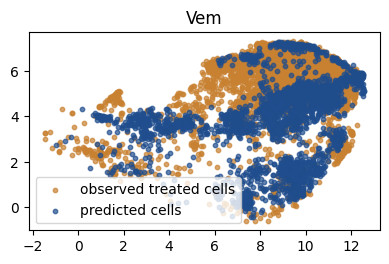

In [6]:
X_pre_COLO858, X_post_COLO858 = prepare_pair_from_mat('COLO858', 'DMSO','24h', 'Vem', '72h')
X_pre_WM902B, X_post_WM902B = prepare_pair_from_mat('WM902B', 'DMSO','24h', 'Vem', '72h')
X_pre_RVH421, X_post_RVH421 = prepare_pair_from_mat('RVH421', 'DMSO','24h', 'Vem', '72h')
X_pre_SKMEL19, X_post_SKMEL19 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', 'Vem', '72h')
drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_WM902B, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_WM902B, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_COLO858
Y_te_post = X_post_COLO858


print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

(6223, 20)
(5690, 20)
(6223, 20)
(5690, 20)


Global seed set to 1234


Median heuristic gamma: 0.06840474985375293
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 52/1000:   5%|█████████▊                                                                                                                                                                                  | 52/1000 [00:30<09:16,  1.70it/s, loss=0.536, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 55.169. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 52/1000:   5%|█████████▊                                                                                                                                                                                   | 52/1000 [00:41<12:35,  1.25it/s, loss=0.54, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 52.888. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/u

Run 9 metrics: {'mmd2_gamma_median': 0.3537697561059783, 'mmd2_gamma_0.5': 0.4280415440362353, 'mmd2_gamma_1.0': 0.30177687819540927, 'wasserstein_distance': 2.4163444966772687, 'R2_feature_means': -0.27769904724910743}
                        mean     std
mmd2_gamma_median     0.3105  0.0695
mmd2_gamma_0.5        0.4009  0.0544
mmd2_gamma_1.0        0.2970  0.0345
wasserstein_distance  2.2583  0.2915
R2_feature_means     -0.0563  0.3175


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


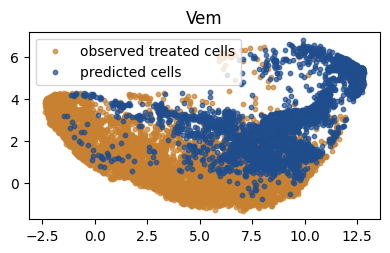

In [7]:
drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_WM902B
Y_te_post = X_post_WM902B

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

(11393, 20)
(520, 20)
(11393, 20)
(520, 20)


Global seed set to 1234


Median heuristic gamma: 0.05812256019223407
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 51/1000:   5%|█████████▌                                                                                                                                                                                  | 51/1000 [01:16<23:44,  1.50s/it, loss=0.515, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 56.020. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 51/1000:   5%|█████████▌                                                                                                                                                                                  | 51/1000 [01:24<26:06,  1.65s/it, loss=0.498, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 61.906. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Run 9 metrics: {'mmd2_gamma_median': 0.06236789139554255, 'mmd2_gamma_0.5': 0.2054990649156635, 'mmd2_gamma_1.0': 0.19462957453043372, 'wasserstein_distance': 1.1702965511529144, 'R2_feature_means': 0.8973780255363506}
                        mean     std
mmd2_gamma_median     0.0966  0.0246
mmd2_gamma_0.5        0.2570  0.0442
mmd2_gamma_1.0        0.2276  0.0306
wasserstein_distance  1.3900  0.1497
R2_feature_means      0.8491  0.0358


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

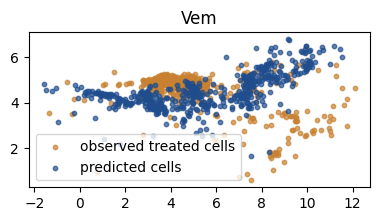

In [8]:

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_RVH421
Y_te_post = X_post_RVH421

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

(9236, 20)
(2677, 20)
(9236, 20)
(2677, 20)


Global seed set to 1234


Median heuristic gamma: 0.05360466243048794
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 51/1000:   5%|█████████▌                                                                                                                                                                                  | 51/1000 [01:07<20:54,  1.32s/it, loss=0.536, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 61.902. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Run 9 metrics: {'mmd2_gamma_median': 0.13015893271863854, 'mmd2_gamma_0.5': 0.3152832823538273, 'mmd2_gamma_1.0': 0.2555994206214468, 'wasserstein_distance': 1.4657710169198086, 'R2_feature_means': 0.8059378711127437}
                        mean     std
mmd2_gamma_median     0.1174  0.0162
mmd2_gamma_0.5        0.2912  0.0305
mmd2_gamma_1.0        0.2423  0.0297
wasserstein_distance  1.4188  0.0846
R2_feature_means      0.8194  0.0291


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


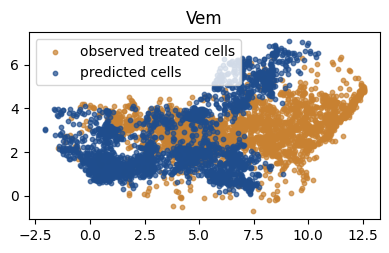

In [9]:

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_RVH421], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_RVH421], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_SKMEL19
Y_te_post = X_post_SKMEL19

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)